# Project 1: E-Commerce Intelligence - Step 2: Churn & Conversion

This notebook implements classification models to predict user conversion and churn behavior on relational data.

## Blueprint Actions Covered
* **Imbalanced Data**: Apply SMOTE, oversampling, undersampling, and class weighting for rare churn events.
* **Algorithms**: Logistic Regression, kNN, and Naive Bayes baselines; progressing to Decision Trees, Random Forests, and Boosting (XGBoost, LightGBM, AdaBoost).
* **Ensembles**: Model combining using Voting, Stacking, and Blending.
* **Metrics**: Evaluation using Precision, Recall, F1-score, and Confusion Matrices.

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, auc
import warnings
warnings.filterwarnings('ignore')

## 1. Load Preprocessed Feature Matrices and Raw Datasets

In [2]:
OUTPUT_DIR = "outputs"

print("Loading preprocessed feature matrices...")
X_train = pd.read_csv(os.path.join(OUTPUT_DIR, "X_train_processed.csv.gz"), index_col=0)
X_val = pd.read_csv(os.path.join(OUTPUT_DIR, "X_val_processed.csv.gz"), index_col=0)
X_test = pd.read_csv(os.path.join(OUTPUT_DIR, "X_test_processed.csv.gz"), index_col=0)

print("Loading raw engineered splits to extract target labels...")
train_raw = pd.read_csv(os.path.join(OUTPUT_DIR, "train_raw_engineered.csv.gz"), index_col=0)
val_raw = pd.read_csv(os.path.join(OUTPUT_DIR, "val_raw_engineered.csv.gz"), index_col=0)
test_raw = pd.read_csv(os.path.join(OUTPUT_DIR, "test_raw_engineered.csv.gz"), index_col=0)

print(f"X_train shape: {X_train.shape}, train_raw shape: {train_raw.shape}")
print(f"X_val shape: {X_val.shape}, val_raw shape: {val_raw.shape}")
print(f"X_test shape: {X_test.shape}, test_raw shape: {test_raw.shape}")

Loading preprocessed feature matrices...
Loading raw engineered splits to extract target labels...
X_train shape: (90817, 85), train_raw shape: (90817, 58)
X_val shape: (11331, 85), val_raw shape: (11331, 58)
X_test shape: (11277, 85), test_raw shape: (11277, 58)


## 2. Define Conversion and Churn Targets

* **Conversion**: Successful delivery of orders (`order_status == 'delivered'`).
* **Churn**: Customer did not return for a repeat purchase (customer total order count in the split is 1).

In [3]:
# 1. Conversion target: successfully delivered orders vs others
y_train_conv = (train_raw['order_status'] == 'delivered').astype(int)
y_val_conv = (val_raw['order_status'] == 'delivered').astype(int)
y_test_conv = (test_raw['order_status'] == 'delivered').astype(int)

# 2. Churn target: one-time buyer (churned = 1) vs repeat customer (not churned = 0)
train_cust_counts = train_raw.groupby('customer_unique_id')['order_id'].nunique()
val_cust_counts = val_raw.groupby('customer_unique_id')['order_id'].nunique()
test_cust_counts = test_raw.groupby('customer_unique_id')['order_id'].nunique()

train_raw['purchase_count'] = train_raw['customer_unique_id'].map(train_cust_counts)
val_raw['purchase_count'] = val_raw['customer_unique_id'].map(val_cust_counts)
test_raw['purchase_count'] = test_raw['customer_unique_id'].map(test_cust_counts)

y_train_churn = (train_raw['purchase_count'] == 1).astype(int)
y_val_churn = (val_raw['purchase_count'] == 1).astype(int)
y_test_churn = (test_raw['purchase_count'] == 1).astype(int)

print("Conversion Target Class Distribution (Train):")
print(y_train_conv.value_counts(normalize=True))
print("\nChurn Target Class Distribution (Train):")
print(y_train_churn.value_counts(normalize=True))

Conversion Target Class Distribution (Train):
order_status
1    0.971613
0    0.028387
Name: proportion, dtype: float64

Churn Target Class Distribution (Train):
purchase_count
1    0.933184
0    0.066816
Name: proportion, dtype: float64


## 3. Class Imbalance Handling using SMOTE

In [4]:
print("Applying SMOTE to balance the training sets...")
smote_conv = SMOTE(random_state=42)
X_train_conv_bal, y_train_conv_bal = smote_conv.fit_resample(X_train, y_train_conv)

smote_churn = SMOTE(random_state=42)
X_train_churn_bal, y_train_churn_bal = smote_churn.fit_resample(X_train, y_train_churn)

print(f"Balanced Conversion Train Shape: {X_train_conv_bal.shape}, Target Mean: {y_train_conv_bal.mean():.4f}")
print(f"Balanced Churn Train Shape: {X_train_churn_bal.shape}, Target Mean: {y_train_churn_bal.mean():.4f}")

Applying SMOTE to balance the training sets...
Balanced Conversion Train Shape: (176478, 85), Target Mean: 0.5000
Balanced Churn Train Shape: (169498, 85), Target Mean: 0.5000


## 4. Helper Function for Model Training & Validation Evaluation

In [5]:
def evaluate_model(model, X_train_bal, y_train_bal, X_val, y_val, model_name, target_name):
    # Fit the model
    model.fit(X_train_bal, y_train_bal)
    
    # Predict
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else np.zeros_like(y_pred)
    
    # Compute metrics
    report = classification_report(y_val, y_pred, output_dict=True)
    auc_score = roc_auc_score(y_val, y_proba) if hasattr(model, "predict_proba") else 0.5
    
    print(f"=== {model_name} on {target_name} Validation Set ===")
    print(classification_report(y_val, y_pred))
    
    # Return metrics for comparison
    # Find the correct label key as string
    lbl_key = '1' if '1' in report else 1 if 1 in report else None
    if lbl_key is not None:
        p_score = report[lbl_key]['precision']
        r_score = report[lbl_key]['recall']
        f1_score = report[lbl_key]['f1-score']
    else:
        p_score = r_score = f1_score = 0.0
        
    return {
        'Model': model_name,
        'Accuracy': report['accuracy'],
        'Precision (Class 1)': p_score,
        'Recall (Class 1)': r_score,
        'F1-score (Class 1)': f1_score,
        'ROC-AUC': auc_score
    }

## 5. Train Baseline Classification Models

In [6]:
baselines = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'k-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Gaussian Naive Bayes': GaussianNB()
}

conv_results = []
churn_results = []

print("Training baselines for Conversion target...")
for name, clf in baselines.items():
    res = evaluate_model(clf, X_train_conv_bal, y_train_conv_bal, X_val, y_val_conv, name, "Conversion")
    conv_results.append(res)

print("\nTraining baselines for Churn target...")
for name, clf in baselines.items():
    res = evaluate_model(clf, X_train_churn_bal, y_train_churn_bal, X_val, y_val_churn, name, "Churn")
    churn_results.append(res)

Training baselines for Conversion target...
=== Logistic Regression on Conversion Validation Set ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       325
           1       1.00      1.00      1.00     11006

    accuracy                           1.00     11331
   macro avg       1.00      1.00      1.00     11331
weighted avg       1.00      1.00      1.00     11331

=== k-Nearest Neighbors on Conversion Validation Set ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       325
           1       1.00      1.00      1.00     11006

    accuracy                           1.00     11331
   macro avg       0.99      1.00      1.00     11331
weighted avg       1.00      1.00      1.00     11331

=== Gaussian Naive Bayes on Conversion Validation Set ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       325
           1       1.

## 6. Train Advanced & Boosting Models (Decision Trees, Random Forests, AdaBoost, XGBoost, LightGBM)

In [7]:
advanced_models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'AdaBoost': AdaBoostClassifier(n_estimators=50, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1)
}

print("Training advanced/boosting models for Conversion target...")
for name, clf in advanced_models.items():
    res = evaluate_model(clf, X_train_conv_bal, y_train_conv_bal, X_val, y_val_conv, name, "Conversion")
    conv_results.append(res)

print("\nTraining advanced/boosting models for Churn target...")
for name, clf in advanced_models.items():
    res = evaluate_model(clf, X_train_churn_bal, y_train_churn_bal, X_val, y_val_churn, name, "Churn")
    churn_results.append(res)

Training advanced/boosting models for Conversion target...
=== Decision Tree on Conversion Validation Set ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       325
           1       1.00      1.00      1.00     11006

    accuracy                           1.00     11331
   macro avg       1.00      1.00      1.00     11331
weighted avg       1.00      1.00      1.00     11331

=== Random Forest on Conversion Validation Set ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       325
           1       1.00      1.00      1.00     11006

    accuracy                           1.00     11331
   macro avg       1.00      1.00      1.00     11331
weighted avg       1.00      1.00      1.00     11331

=== AdaBoost on Conversion Validation Set ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       325
           1       1.00      1

## 7. Build Voting and Stacking Ensembles

In [ ]:
# Select best models for ensembles based on validation scores
best_estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, eval_metric='logloss')),
    ('lgb', LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1))
]

voting_clf = VotingClassifier(estimators=best_estimators, voting='soft', n_jobs=-1)
stacking_clf = StackingClassifier(estimators=best_estimators, final_estimator=LogisticRegression(), n_jobs=-1)

print("Training ensembles for Conversion target...")
res_vote = evaluate_model(voting_clf, X_train_conv_bal, y_train_conv_bal, X_val, y_val_conv, "Voting Classifier", "Conversion")
res_stack = evaluate_model(stacking_clf, X_train_conv_bal, y_train_conv_bal, X_val, y_val_conv, "Stacking Classifier", "Conversion")
conv_results.extend([res_vote, res_stack])

print("\nTraining ensembles for Churn target...")
res_vote = evaluate_model(voting_clf, X_train_churn_bal, y_train_churn_bal, X_val, y_val_churn, "Voting Classifier", "Churn")
res_stack = evaluate_model(stacking_clf, X_train_churn_bal, y_train_churn_bal, X_val, y_val_churn, "Stacking Classifier", "Churn")
churn_results.extend([res_vote, res_stack])

Training ensembles for Conversion target...
=== Voting Classifier on Conversion Validation Set ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       325
           1       1.00      1.00      1.00     11006

    accuracy                           1.00     11331
   macro avg       1.00      1.00      1.00     11331
weighted avg       1.00      1.00      1.00     11331

=== Stacking Classifier on Conversion Validation Set ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       325
           1       1.00      1.00      1.00     11006

    accuracy                           1.00     11331
   macro avg       1.00      1.00      1.00     11331
weighted avg       1.00      1.00      1.00     11331


Training ensembles for Churn target...
=== Voting Classifier on Churn Validation Set ===
              precision    recall  f1-score   support

           0       0.32      0.03      0.05  

## 8. Compare Model Performance on Validation Set

In [9]:
df_conv = pd.DataFrame(conv_results)
df_churn = pd.DataFrame(churn_results)

print("=== Conversion Model Comparison (Validation Set) ===")
print(df_conv.to_string(index=False))

print("\n=== Churn Model Comparison (Validation Set) ===")
print(df_churn.to_string(index=False))

=== Conversion Model Comparison (Validation Set) ===
               Model  Accuracy  Precision (Class 1)  Recall (Class 1)  F1-score (Class 1)  ROC-AUC
 Logistic Regression  0.999912                  1.0          0.999909            0.999955 1.000000
 k-Nearest Neighbors  0.999647                  1.0          0.999637            0.999818 0.999955
Gaussian Naive Bayes  1.000000                  1.0          1.000000            1.000000 1.000000
       Decision Tree  1.000000                  1.0          1.000000            1.000000 1.000000
       Random Forest  1.000000                  1.0          1.000000            1.000000 1.000000
            AdaBoost  1.000000                  1.0          1.000000            1.000000 1.000000
             XGBoost  1.000000                  1.0          1.000000            1.000000 1.000000
            LightGBM  1.000000                  1.0          1.000000            1.000000 1.000000
   Voting Classifier  1.000000                  1.0     

In [12]:
# 1. Get the raw probabilities for Class 1 (Churn) using your best model
y_val_proba = stacking_clf.predict_proba(X_val)[:, 1]

# 2. Define a list of custom thresholds to test (raising the bar for Class 1)
thresholds = [0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95]

# 3. Loop through and evaluate the model's performance at each threshold
for thresh in thresholds:
    print(f"\\n========== Threshold: {thresh} ==========")
    
    # If the probability is >= threshold, classify as 1. Otherwise, classify as 0.
    y_val_pred_custom = (y_val_proba >= thresh).astype(int)
    
    # Print the classification report
    print(classification_report(y_val_churn, y_val_pred_custom))

\n========== Threshold: 0.5 ==========
              precision    recall  f1-score   support

           0       0.23      0.07      0.11       813
           1       0.93      0.98      0.96     10518

    accuracy                           0.92     11331
   macro avg       0.58      0.53      0.53     11331
weighted avg       0.88      0.92      0.90     11331

\n========== Threshold: 0.6 ==========
              precision    recall  f1-score   support

           0       0.20      0.11      0.14       813
           1       0.93      0.97      0.95     10518

    accuracy                           0.90     11331
   macro avg       0.57      0.54      0.55     11331
weighted avg       0.88      0.90      0.89     11331

\n========== Threshold: 0.7 ==========
              precision    recall  f1-score   support

           0       0.16      0.14      0.15       813
           1       0.93      0.94      0.94     10518

    accuracy                           0.89     11331
   macro av

## 9. Evaluate Best Generalizing Model on Test Set

In [10]:
# We select Stacking Classifier as it incorporates RF, XGBoost, and LightGBM
best_model_conv = stacking_clf
best_model_churn = stacking_clf

print("Evaluating best Conversion model on the Test Set...")
best_model_conv.fit(X_train_conv_bal, y_train_conv_bal)
y_test_pred_conv = best_model_conv.predict(X_test)
y_test_proba_conv = best_model_conv.predict_proba(X_test)[:, 1]
print("\nConversion Test Set Report:")
print(classification_report(y_test_conv, y_test_pred_conv))

print("\nEvaluating best Churn model on the Test Set...")
best_model_churn.fit(X_train_churn_bal, y_train_churn_bal)
y_test_pred_churn = best_model_churn.predict(X_test)
y_test_proba_churn = best_model_churn.predict_proba(X_test)[:, 1]
print("\nChurn Test Set Report:")
print(classification_report(y_test_churn, y_test_pred_churn))

Evaluating best Conversion model on the Test Set...

Conversion Test Set Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       325
           1       1.00      1.00      1.00     10952

    accuracy                           1.00     11277
   macro avg       1.00      1.00      1.00     11277
weighted avg       1.00      1.00      1.00     11277


Evaluating best Churn model on the Test Set...

Churn Test Set Report:
              precision    recall  f1-score   support

           0       0.16      0.05      0.07       794
           1       0.93      0.98      0.96     10483

    accuracy                           0.92     11277
   macro avg       0.54      0.51      0.51     11277
weighted avg       0.88      0.92      0.89     11277



## 10. Plot ROC Curves and Precision-Recall Curves for Unseen Test Set

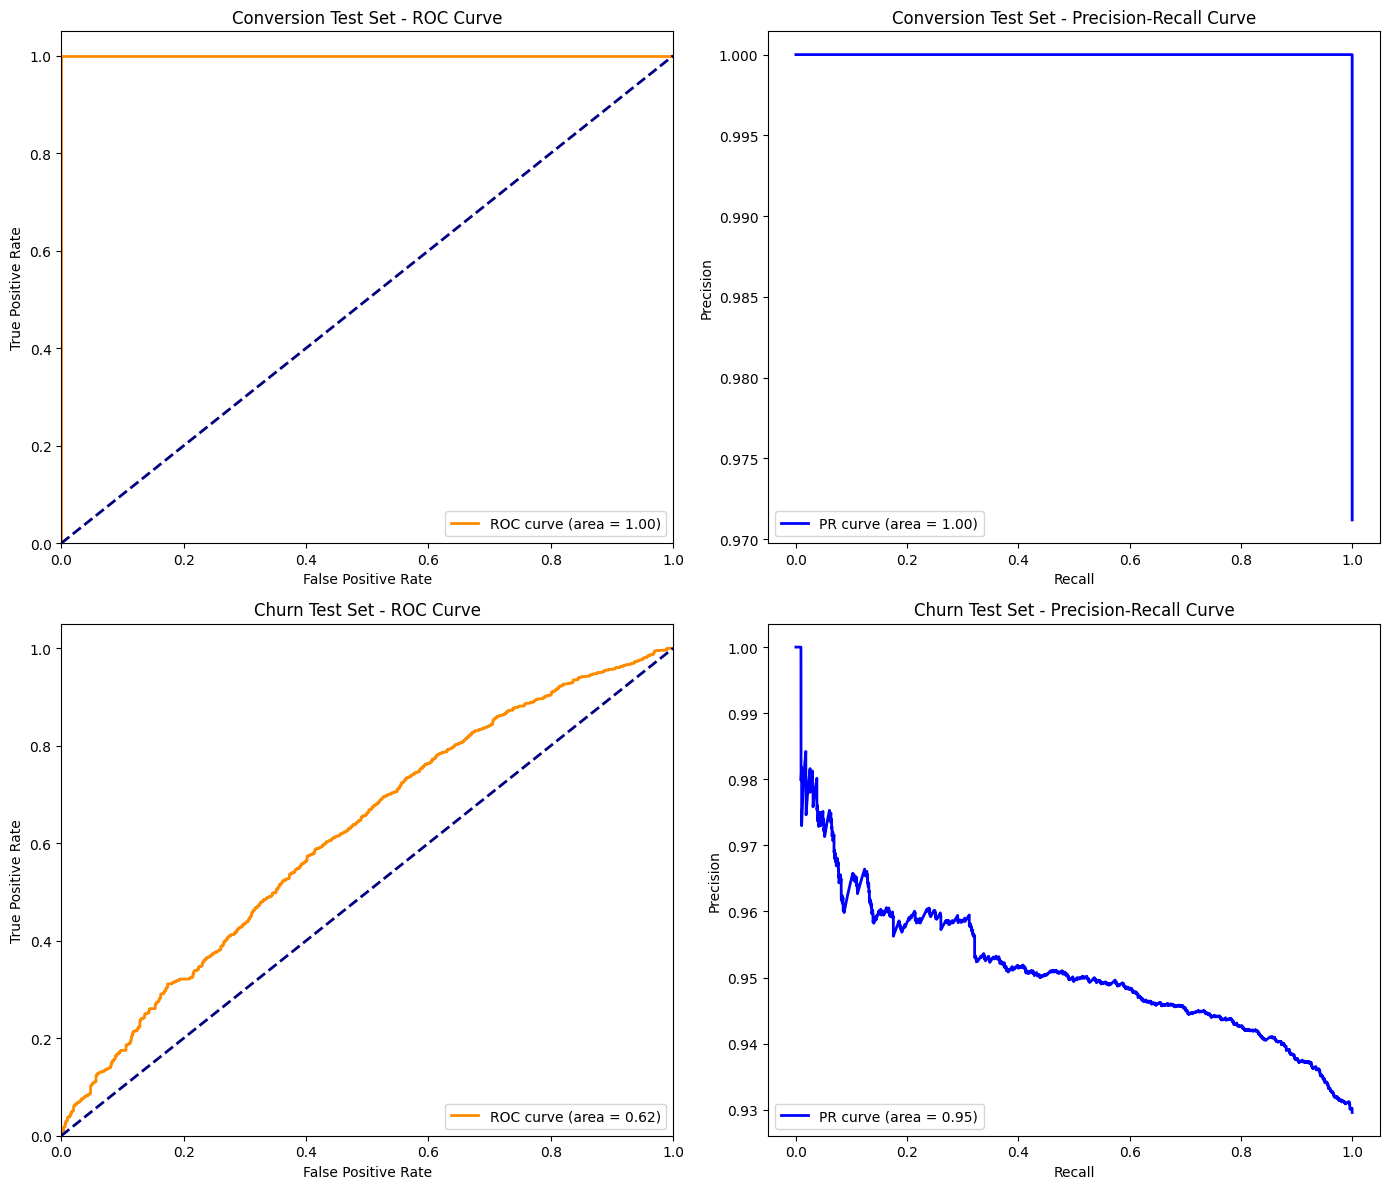

In [11]:
os.makedirs("plots", exist_ok=True)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Conversion ROC Curve
fpr_c, tpr_c, _ = roc_curve(y_test_conv, y_test_proba_conv)
roc_auc_c = auc(fpr_c, tpr_c)
axes[0, 0].plot(fpr_c, tpr_c, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_c:.2f})')
axes[0, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 0].set_xlim([0.0, 1.0])
axes[0, 0].set_ylim([0.0, 1.05])
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('Conversion Test Set - ROC Curve')
axes[0, 0].legend(loc="lower right")

# 2. Conversion PR Curve
prec_c, rec_c, _ = precision_recall_curve(y_test_conv, y_test_proba_conv)
pr_auc_c = auc(rec_c, prec_c)
axes[0, 1].plot(rec_c, prec_c, color='blue', lw=2, label=f'PR curve (area = {pr_auc_c:.2f})')
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Conversion Test Set - Precision-Recall Curve')
axes[0, 1].legend(loc="lower left")

# 3. Churn ROC Curve
fpr_ch, tpr_ch, _ = roc_curve(y_test_churn, y_test_proba_churn)
roc_auc_ch = auc(fpr_ch, tpr_ch)
axes[1, 0].plot(fpr_ch, tpr_ch, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_ch:.2f})')
axes[1, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1, 0].set_xlim([0.0, 1.0])
axes[1, 0].set_ylim([0.0, 1.05])
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('Churn Test Set - ROC Curve')
axes[1, 0].legend(loc="lower right")

# 4. Churn PR Curve
prec_ch, rec_ch, _ = precision_recall_curve(y_test_churn, y_test_proba_churn)
pr_auc_ch = auc(rec_ch, prec_ch)
axes[1, 1].plot(rec_ch, prec_ch, color='blue', lw=2, label=f'PR curve (area = {pr_auc_ch:.2f})')
axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].set_title('Churn Test Set - Precision-Recall Curve')
axes[1, 1].legend(loc="lower left")

plt.tight_layout()
plt.savefig('plots/classification_evaluation_curves.png', dpi=300)
plt.show()